In [1]:
# パラメータの更新

In [2]:
# SGD
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr  

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

In [5]:
# SGDの欠点

In [6]:
# Momentum
import numpy as np

class Momentum:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)

        for key in params.keys():
            self.v[key] = self.momentum*self.v[key] - self.le*grads[key]
            params[key] += self.v[key]

In [7]:
# AdaGradの実装
class AdaGrad:
    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.key():
            self.h[key] += grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)


In [8]:
# Adam

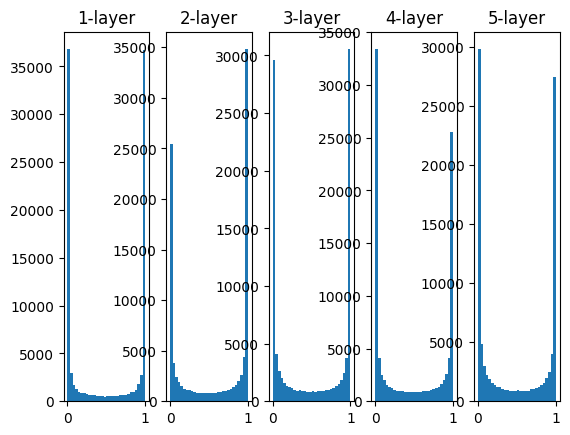

In [12]:
# 隠れそう之アクティベーション分布
import numpy as np
import matplotlib.pyplot as plt
from ch06.weight_init_activation_histogram import activations

rng = np.random.default_rng()

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = rng.standard_normal((1000, 100))
node_num = 100
hidden_layer_size = 5
activations = {}

for i in range(hidden_layer_size):
    if i != 0:
        x = activations[i-1]

    w = rng.standard_normal((node_num, node_num)) * 1

    z = np.dot(x, w)
    a = sigmoid(z)
    activations[i] = a

# ヒストグラムを描画
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    plt.hist(a.flatten(), 30, range=(0,1))

plt.show()